# Фракталы и комплексная динамика

## Базовый уровень

### Множество Мандельброта

Реализуем визуализацию множества Мандельброта для комплексного отображения $z_{n+1} = z_n^2 + c$, где $c \in [-2, 1] \times [-1.5i, 1.5i]$.

В качестве критерия для определения расхождения используется $|z| > 2$ или число итераций $\gt 100$.

Импортируем необходимые модули.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

Зададим параметры подобласти в комплексной плоскости и параметры для критерия расхождения (`R` = 2, `max_iter` = 100).

In [11]:
max_iter = 100
R = 2

x_min = -2.0
x_max = 1.0
y_min = -1.5
y_max = 1.5
x_steps = 1000
y_steps = 1000
dx = (x_max - x_min) / x_steps
dy = (y_max - y_min) / y_steps

mandelbrot = np.zeros((y_steps, x_steps))

Строим множество Мандельброта: для каждой точки $c$ подобласти запускаем цикл, на каждой итерации которого применяем к ней комплексное отображение $z_{n+1} = z_n^2 + c$, где $z_0 = c$, и проверяем, соответствует ли её новое значение критерию расхождения.

In [12]:
for i in range(x_steps):
    for j in range(y_steps):
        c = complex(dx * i + x_min,
                    dy * j + y_min)
        z = c
        iter = 0
        while abs(z) <= R and iter <= max_iter:
            z = z ** 2 + c
            iter += 1
        mandelbrot[j][i] = iter

Визуализируем множество Мандельброта.

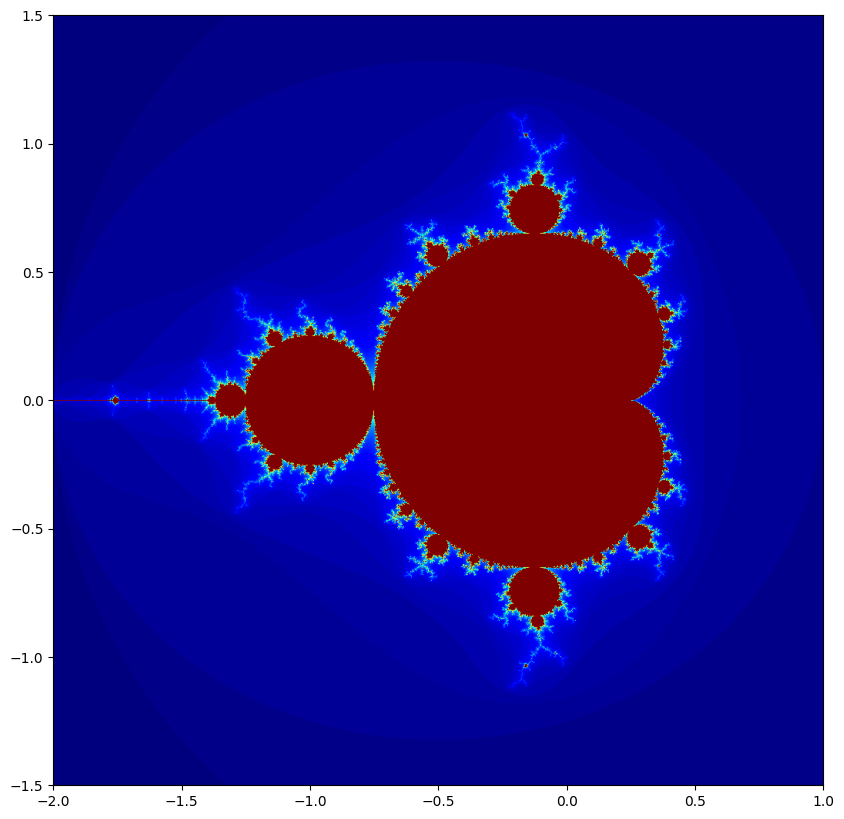

In [13]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(mandelbrot, cmap='jet', extent=[x_min, x_max, y_min, y_max])
plt.show()

### Множество Джулиа

Множество Джулиа для каждого отдельного $c$ строится похожим образом: задано значение $c$ и для каждой точки $a$ из рассматриваемой подобласти проводится описанная выше процедура с $z_{n+1} = z_n^2 + c$ и $z_0 = a$.

Реализуем отдельную функцию `make_julia_set` для построения множества Джулиа.

In [14]:
def make_julia_set(c, max_iter = 100, R = 2, x_min = -1.5, x_max = 1.5, y_min = -1.5, y_max = 1.5, x_steps = 1000, y_steps = 1000):
    dx = (x_max - x_min) / x_steps
    dy = (y_max - y_min) / y_steps
    julia = np.zeros((y_steps, x_steps))
    
    for i in range(x_steps):
        for j in range(y_steps):
            z = complex(dx * i + x_min,
                        dy * j + y_min)
            iter = 0
            while abs(z) <= R and iter <= max_iter:
                z = z ** 2 + c
                iter += 1
            julia[j][i] = iter

    return julia

Построим множество Джулиа для точки $c = -0.7 + 0.25i$, расположенной внутри множества Мандельброта.

Получаем связное множество.

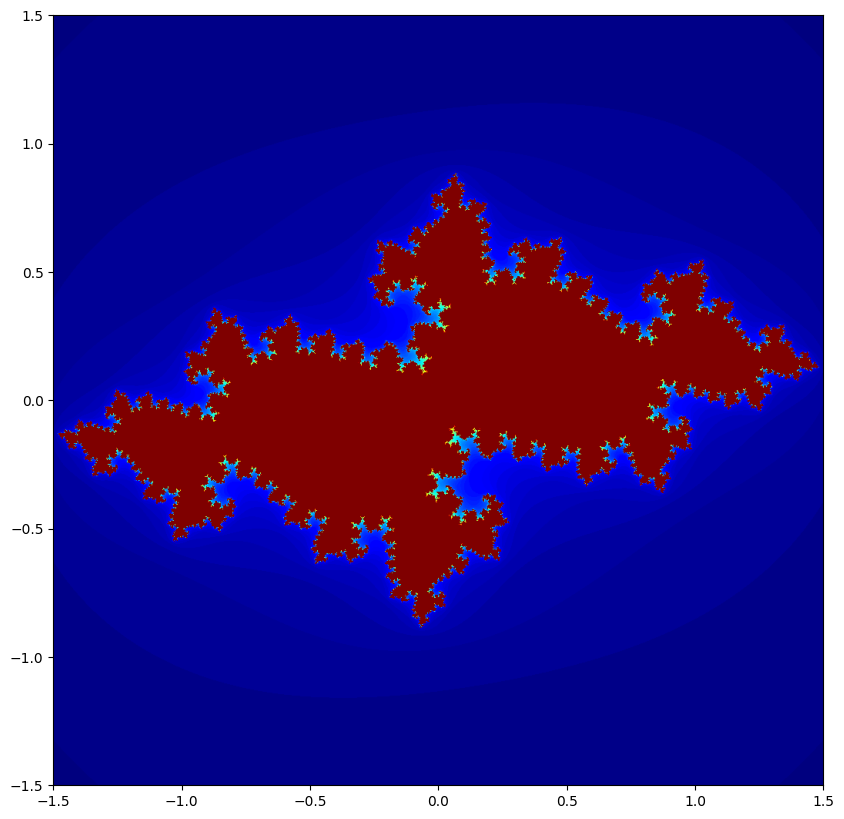

In [15]:
julia = make_julia_set(complex(-0.7, 0.25))
fig = plt.figure(figsize=(10, 10))
plt.imshow(julia, cmap='jet', extent=[-1.5, 1.5, -1.5, 1.5])
plt.show()

Для точки $c = -0.75 + 0.25i$, расположенной вне множества Мандельброта, множество Джулиа несвязно.

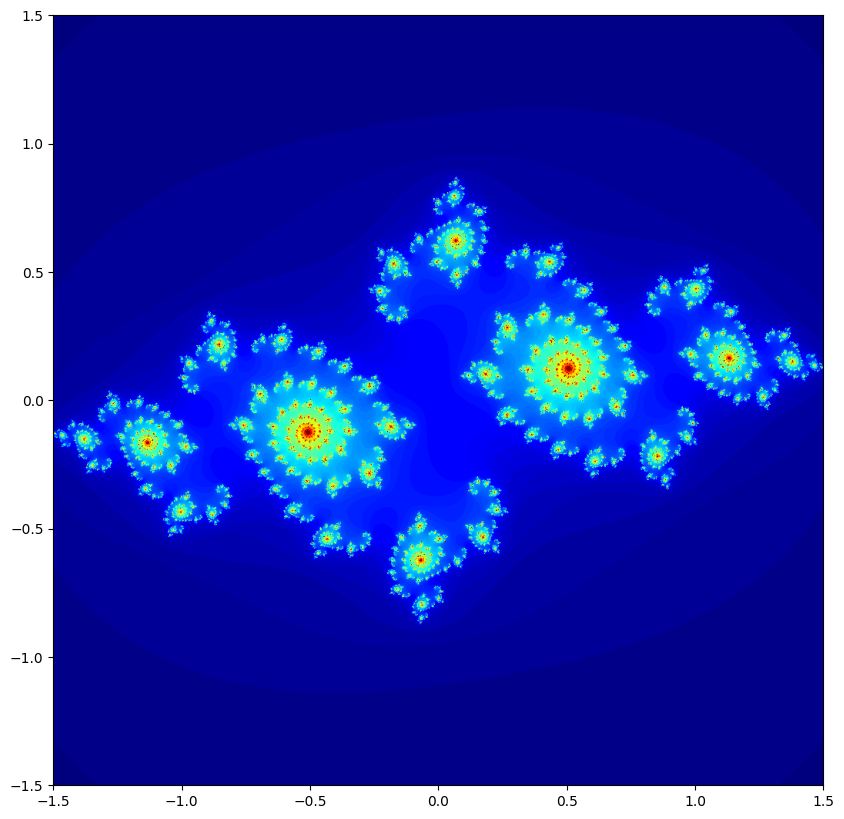

In [7]:
julia = make_julia_set(complex(-0.75, 0.25))
fig = plt.figure(figsize=(10, 10))
plt.imshow(julia, cmap='jet', extent=[-1.5, 1.5, -1.5, 1.5])
plt.show()

Исследуем точки, близкие к границе множества Мандельброта ($c = -0.725 + 0.25i$, $c = -0.835 - 0.2321i$).

При пересечении границы множества Мандельброта соответствующее множество Джулиа перестаёт быть связным.

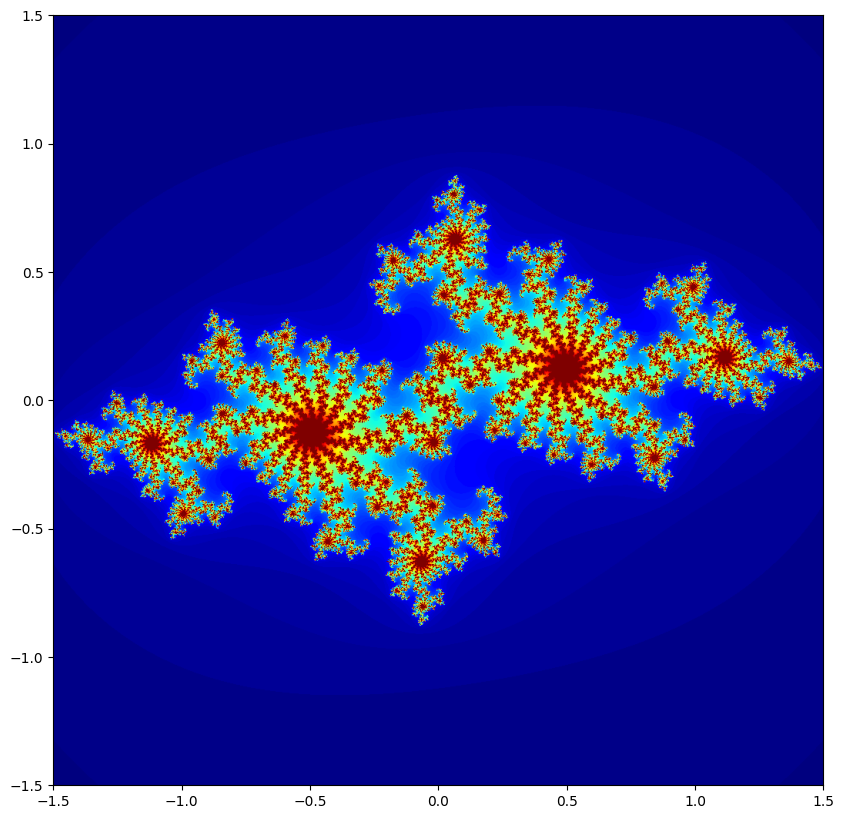

In [8]:
julia = make_julia_set(complex(-0.725, 0.25))
fig = plt.figure(figsize=(10, 10))
plt.imshow(julia, cmap='jet', extent=[-1.5, 1.5, -1.5, 1.5])
plt.show()

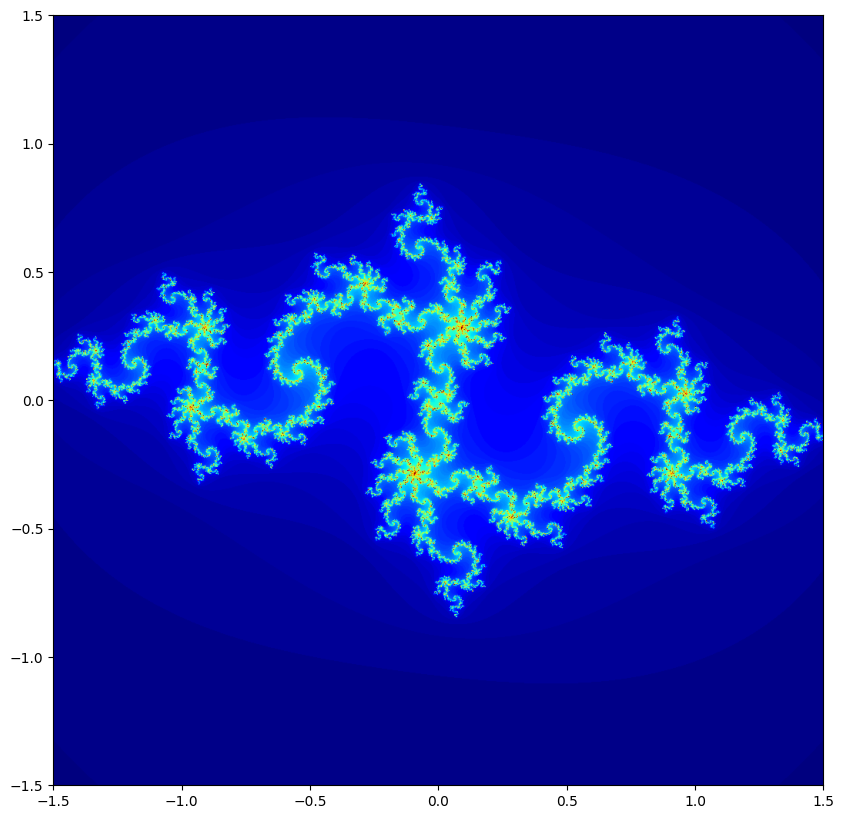

In [9]:
julia = make_julia_set(complex(-0.835, -0.2321))
fig = plt.figure(figsize=(10, 10))
plt.imshow(julia, cmap='jet', extent=[-1.5, 1.5, -1.5, 1.5])
plt.show()